        Disable GPU: Force tensorflow to select CPU

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="-1"    
import tensorflow as tf

2025-07-02 22:30:42.129503: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751475642.149606  224281 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751475642.155768  224281 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-02 22:30:42.176268: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


        Select a GPU with a memory limit

In [1]:
#%% # include ../dirx 
import tensorflow as tf
print(f"TensorFlow version {tf.__version__}")
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
gpus = tf.config.list_physical_devices('GPU')
len(gpus)
mylibpath = [
    '/home/kishoretarafdar/bin'
    ]
import sys
[sys.path.insert(1,_) for _ in mylibpath]
del mylibpath

from tf_select_a_gpu import select_a_gpu
# select_gpu = gpus[gpu_id]
memory_limit = 16#32 #GB
select_a_gpu(gpus, gpu_id = 2, memory_limit=memory_limit)
# del gpu_id, select_a_gpu, select_gpu

# from DWT1DFB import DWT1D, IDWT1D
# from DWT2DFB import DWT2D, IDWT2D


2025-07-03 00:36:15.856100: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751483175.876905  262888 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751483175.883276  262888 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-03 00:36:15.905080: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version 2.18.0
Num GPUs Available:  3
3 Physical GPUs available 
Selected 1 Logical GPU with 16 GB memory limit


I0000 00:00:1751483177.993279  262888 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 16384 MB memory:  -> device: 2, name: NVIDIA RTX A6000, pci bus id: 0000:41:00.0, compute capability: 8.6


In [155]:
# mylibpath = [
#     '/data1/kishoretarafdar/src.port/VolterraMRAsystems.v0/linear.Volterra.mra.live/mra'
#     ]
# import sys
# [sys.path.insert(1,_) for _ in mylibpath]
# del mylibpath
# from DWT1DFB import DWT1D, IDWT1D

In [15]:
import matplotlib.pyplot as plt

#  MIMO batch
        
        export to py file

In [ ]:

#%% Shift invariant Linear (m=1) Multiresolution Volterra Kernel
import tensorflow as tf
import keras
from TFDWT.DWT1DFB import DWT1D, IDWT1D

@tf.keras.utils.register_keras_serializable()
class LSIVolterraMRAKernel1D(tf.keras.layers.Layer):
    """ VolterraSys: Multidimensional linear and nonlinear Volterra kernels in natural and multiresolution bases.
        Copyright (C) 2025 Kishore Kumar Tarafdar

        This program is free software: you can redistribute it and/or modify
        it under the terms of the GNU General Public License as published by
        the Free Software Foundation, either version 3 of the License, or
        (at your option) any later version.

        This program is distributed in the hope that it will be useful,
        but WITHOUT ANY WARRANTY; without even the implied warranty of
        MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
        GNU General Public License for more details.

        You should have received a copy of the GNU General Public License
        along with this program.  If not, see <https://www.gnu.org/licenses/>.   
        
    
    Shift invariant Linear (m=1) Multiresolution Volterra Kernel
        Input: sequence x[n]
        Output: Shift invariant linear monomial y1, i.e., m=1

    --@KKT@03Jul2025"""
    
    def __init__(self, filters=1, kernel_size=4, wave='haar', **kwargs):
        super().__init__(**kwargs)
        self.L = kernel_size
        self.wave = wave
        self.filters = filters
    
    def build(self, input_shape):
        # input_shape: (batch_size, N, N, channels)
        self.N = input_shape[1]
        self.channels = input_shape[-1]
   
        kernel_shape = (self.L, input_shape[-1], self.filters)
        # kernel_shape = (self.L, input_shape[-1])
        self.h1 = self.add_weight(
            shape=kernel_shape,
            initializer='glorot_uniform',
            trainable=True,
            # regularizer=self.kernel_regularizer,
            name='kernel')
        super().build(input_shape)

    def __makeH(self):
        paddings = [
        [0, self.N - self.L],  # Depth dimension
        [0,0],
        [0,0]
        ]
        h_padded = tf.pad(self.h1, paddings, mode='CONSTANT', constant_values=0)
        # print(h_padded.shape,'>')

        ## Creating x[n-k] for all n

        n = tf.range(self.N)
        self.row_indices = tf.math.mod(n[:, tf.newaxis] - n, self.N)

        hshifted = tf.gather(h_padded, self.row_indices, axis=0)
        # print(hshifted.shape,'>')
        # print(tf.concat([tf.transpose(DWT1D(self.wave)(tf.transpose(DWT1D(self.wave)(hshifted[...,i:i+1]), perm=[1,0,2])),perm=[1,0,2]) for i in range(self.channels)], axis=-1))

        #### PERFECT but slow
        # HT = tf.stack([
        #         tf.concat([
        #             tf.transpose(DWT1D(self.wave, clean=False)(tf.transpose(DWT1D(self.wave, clean=False)(hshifted[...,i:i+1,j]), perm=[1,0,2])),perm=[1,0,2]) for i in range(self.channels)
        #             ], axis=-1) for j in range(self.filters)], axis=-1)
        # # print(HT.shape)
        # return HT

        ## UPDATE
        # Vectorized: flatten last two axes for DWT
        dwt1 = DWT1D(self.wave, clean=False)
        tmp_h_for_dwt = tf.reshape(hshifted, (self.N, self.N, self.channels * self.filters))
        ## x is dummy here
        x = dwt1(tmp_h_for_dwt)           # (N, dwt_len, in_channels*out_channels)
        # 3. Transpose to swap axes 0 and 1 ("rows" and "columns")
        xT = tf.transpose(x, perm=[1, 0, 2])  # (N', N, in_channels * out_channels)

        # 4. DWT1D along the original rows (now axis=1)
        x2 = dwt1(xT)  # (N', N'', in_channels * out_channels)

        # 5. Transpose back to original orientation
        x2T = tf.transpose(x2, perm=[1, 0, 2])  # (N'', N', in_channels * out_channels)

        # 6. Reshape back to (N'', N', in_channels, out_channels)
        HT = tf.reshape(x2T, (self.N, self.N, self.channels, self.channels))
        return HT
        
    
    

    def call(self, x):  
        ## H[v,l] 
        α = DWT1D(self.wave, clean=False)(x) 
        # print('α = ', α.shape)
        HT = self.__makeH()
        print('HT and α', HT.shape, α.shape)
        β = tf.einsum('bic,uico->buco', α, HT)
        β = tf.einsum('buco->buo',β)
        print('β', β.shape)

        # HTα = HT * α
        # print(HTα.shape, '\n', tf.squeeze(HTα).numpy())
        # beta = tf.expand_dims(tf.einsum('ijk->ik',HTα), axis=-1)
        
        # βT = tf.transpose(beta, perm=[1,0,2])
        # print('βT',tf.squeeze(βT).numpy())
        y = IDWT1D(self.wave, clean=False)(β)#
        # print('y',tf.squeeze(y).numpy())

        return y#, ynatural
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'kernel_size': self.L,
            'wavelet': self.wave,
            'filters': self.filters,
        })
        return config


if __name__=='__main__':

    import os
    os.environ["CUDA_VISIBLE_DEVICES"]="-1"  

    ## Example 1    
    lay = LSIVolterraMRAKernel1D(filters=1)
    ## sample batch input
    x = tf.constant([1,2,3,5,5,3,2,1], dtype=tf.float32)
    x = tf.constant([1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,1], dtype=tf.float32)
    _ = tf.expand_dims(tf.expand_dims(x,axis=-1),axis=0)
    _.shape
    y = lay(_)
    y.shape
    # y = lay(xx)
    # y = lay(tf.concat([xx,xx], axis=-1))
    # y.shape


    ## Example 2
    # Functional model
    N, channels, filters = 4, 1, 1
    input_shape = (N, channels)  # Replace N with the actual size of x            #1D
    inputs = tf.keras.Input(shape=input_shape)
    H = LSIVolterraMRAKernel1D(filters=1)
    outputs = H(inputs)
    # Build the model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse', jit_compile=False)
    model.summary()
    # Random data
    ## 1D
    inputs_data = tf.random.normal((1, N, 1))
    targets = tf.random.normal((1, N, 1))
    # Training loop for 5 epochs
    epochs=5
    # for epoch in range(5):
    history = model.fit(inputs_data, targets, epochs=5, verbose=1)

HT and α (16, 16, 1, 1) (1, 16, 1)
β (1, 16, 1)
HT and α (4, 4, 1, 1) (None, 4, 1)
β (None, 4, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lsi_volterra_mra_kernel1d_1     │ (None, 4, 1)           │             4 │
│ (LSIVolterraMRAKernel1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
HT and α (4, 4, 1, 1) (None, 4, 1)
β (None, 4, 1)
HT and α (4, 4, 1, 1) (None, 4, 1)
β (None, 4, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 1.4164
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1.4125
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.4086
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1.4048
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1.4009


In [ ]:
# x = tf.constant([1,2,3,5,5,3,2,1], dtype=tf.float32)
# x = tf.constant([1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,1], dtype=tf.float32)
# x = tf.constant([1,0,0,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([0,0,1,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0], dtype=tf.float32)
# x = tf.constant([0,1,0,0], dtype=tf.float32)
# x = tf.constant([0,0,1,0], dtype=tf.float32)
# x = tf.constant([3.,0,7.,0], dtype=tf.float32)
# x = tf.constant([1.,7.,11.,13.], dtype=tf.float32)
# x = tf.constant([3.,7.], dtype=tf.float32)
# x = tf.constant([1,1,1,1], dtype=tf.float32)
# x = tf.constant([21,3,4,5], dtype=tf.float32)
# x = tf.constant([.1,.1,.1,.1], dtype=tf.float32)
x.shape

TensorShape([16])

        batch test

In [4]:
## sample batch input
x = tf.constant([1,2,3,5,5,3,2,1], dtype=tf.float32)
x = tf.constant([1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,1], dtype=tf.float32)
_ = tf.expand_dims(tf.expand_dims(x,axis=-1),axis=0)
_.shape

TensorShape([1, 16, 1])

        compute output

In [5]:
y = lay(_)
y.shape

HT and α (16, 16, 1, 1) (1, 16, 1)
β (1, 16, 1)


TensorShape([1, 16, 1])

        check layer's filter

In [6]:
h1 = lay.h1.numpy()
h1.shape

(4, 1, 1)

        fit a sample model

In [7]:
# Functional model
N, channels, filters = 4, 1, 1
input_shape = (N, channels)  # Replace N with the actual size of x            #1D
# input_shape = (N, N, channels)  # Replace N with the actual size of x       #2D
# input_shape = (N, N, N, channels)  # Replace N with the actual size of x    #3D
# input_shape = (N, N, N, N, channels)  # Replace N with the actual size of x    #4D
# input_shape = (N, N, N, N, N, channels)  # Replace N with the actual size of x    #5D
# input_shape = (N, N, N, N, N, N, channels)  # Replace N with the actual size of x    #6D

inputs = tf.keras.Input(shape=input_shape)

# Create an instance of the custom layer
# h2 = np.array([[1, 2], 
#           [1, 3]]).astype(np.float32)
# H = TraceConv1Dio(kernel=tf.expand_dims(h2, axis=-1))
# (tf.expand_dims(tf.expand_dims(x2,axis=0),axis=-1))

#conv1d_filters=32, conv1d_kernel_size=3, 
#  conv2d_filters=32, conv2d_kernel_size=3)

# Apply the custom layer to the inputs
H = LSIVolterraMRAKernel1D(filters=1)
outputs = H(inputs)

# Build the model
model = tf.keras.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='mse', jit_compile=False)
model.summary()

# Random data
## 1D
inputs_data = tf.random.normal((1, N, 1))
targets = tf.random.normal((1, N, 1))
## 2D
# inputs_data = tf.random.normal((1, N, N, 1))
# targets = tf.random.normal((1, N, N, 1))
## 3D
# inputs_data = tf.random.normal((1, N, N, N, 1))
# targets = tf.random.normal((1, N, N, N, 1))
## 4D
# inputs_data = tf.random.normal((1, N, N, N, N, 1))
# targets = tf.random.normal((1, N, N, N, N, 1))
## 5D
# inputs_data = tf.random.normal((1, N, N, N, N, N, 1))
# targets = tf.random.normal((1, N, N, N, N, N, 1))
## 6D
# inputs_data = tf.random.normal((1, N, N, N, N, N, N, 1))
# targets = tf.random.normal((1, N, N, N, N, N, N, 1))


# Training loop for 5 epochs
epochs=5
# for epoch in range(5):
history = model.fit(inputs_data, targets, epochs=5, verbose=1)

HT and α (4, 4, 1, 1) (None, 4, 1)
β (None, 4, 1)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 4, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lsi_volterra_mra_kernel1d_3     │ (None, 4, 1)           │             4 │
│ (LSIVolterraMRAKernel1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
HT and α (4, 4, 1, 1) (None, 4, 1)
β (None, 4, 1)
HT and α (4, 4, 1, 1) (None, 4, 1)
β (None, 4, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 733ms/step - loss: 2.1278
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 2.1221
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 2.1164
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 2.1107
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 2.1050


In [51]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

3 Verify
---

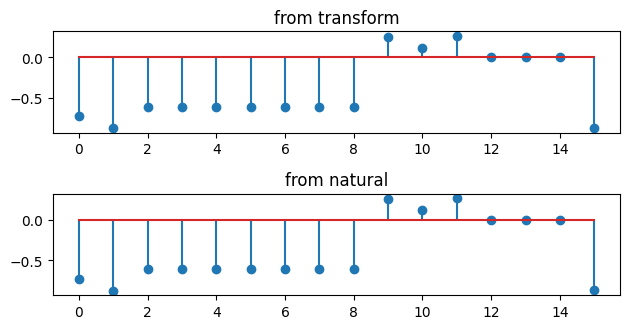

In [100]:
# plt.subplot(3,1,1), plt.stem(tf.squeeze(yhat).numpy())
plt.subplot(3,1,2), plt.stem(tf.squeeze(y).numpy()), plt.title('from transform')
plt.subplot(3,1,3), plt.stem(tf.squeeze(y1n).numpy()), plt.title('from natural')
plt.tight_layout()

In [ ]:
tf.reduce_sum(tf.square(tf.squeeze(yhat))).numpy(), tf.reduce_sum(tf.square(tf.squeeze(y1n))).numpy(), tf.reduce_sum(tf.square(tf.squeeze(y))).numpy()


(np.float32(24.803284), np.float32(24.803291), np.float32(24.803291))

In [ ]:
break

2 BUILD
---

        use the layer's filter for checking equivalent output in natural domain



In [89]:
# x = [0,0,0,0,1,1,1,1]
wave = 'haar'
# wave = 'db2'
wave = 'db3'

## filter init
# h = tf.constant([1,2,3,5], dtype=tf.float32)
h = tf.squeeze(lay.h1.numpy())
# h = tf.constant([1,2,3,4], dtype=tf.float32)
# h = tf.constant([1,1,1,1], dtype=tf.float32)
# h = tf.constant([1,1], dtype=tf.float32)

# h = tf.constant([1.,5.], dtype=tf.float32)
# h = tf.constant([1,0,0,0], dtype=tf.float32)
## Matching filter size with input size with zero padding
x.shape, h.shape

(TensorShape([16]), TensorShape([4]))

        prepare hshifted (extra work)

In [93]:
L = h.shape[0]

# row_indices = tf.math.mod(n[:, tf.newaxis] - n, L)
Npoint = len(x)
paddings = [
           [0, Npoint - L],  # Depth dimension
        ]
h_padded = tf.pad(h, paddings, mode='CONSTANT', constant_values=0)
h_padded.shape


## Creating x[n-k] for all n
N = Npoint
n = tf.range(N)
row_indices = tf.math.mod(n[:, tf.newaxis]-n, N)
print(row_indices)
hshifted = tf.gather(h_padded, row_indices, axis=0)
print(x.shape, h_padded.shape, hshifted.shape), 
x, h_padded, hshifted

tf.Tensor(
[[ 0 15 14 13 12 11 10  9  8  7  6  5  4  3  2  1]
 [ 1  0 15 14 13 12 11 10  9  8  7  6  5  4  3  2]
 [ 2  1  0 15 14 13 12 11 10  9  8  7  6  5  4  3]
 [ 3  2  1  0 15 14 13 12 11 10  9  8  7  6  5  4]
 [ 4  3  2  1  0 15 14 13 12 11 10  9  8  7  6  5]
 [ 5  4  3  2  1  0 15 14 13 12 11 10  9  8  7  6]
 [ 6  5  4  3  2  1  0 15 14 13 12 11 10  9  8  7]
 [ 7  6  5  4  3  2  1  0 15 14 13 12 11 10  9  8]
 [ 8  7  6  5  4  3  2  1  0 15 14 13 12 11 10  9]
 [ 9  8  7  6  5  4  3  2  1  0 15 14 13 12 11 10]
 [10  9  8  7  6  5  4  3  2  1  0 15 14 13 12 11]
 [11 10  9  8  7  6  5  4  3  2  1  0 15 14 13 12]
 [12 11 10  9  8  7  6  5  4  3  2  1  0 15 14 13]
 [13 12 11 10  9  8  7  6  5  4  3  2  1  0 15 14]
 [14 13 12 11 10  9  8  7  6  5  4  3  2  1  0 15]
 [15 14 13 12 11 10  9  8  7  6  5  4  3  2  1  0]], shape=(16, 16), dtype=int32)
(16,) (16,) (16, 16)


(<tf.Tensor: shape=(16,), dtype=float32, numpy=
 array([1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 1.],
       dtype=float32)>,
 <tf.Tensor: shape=(16,), dtype=float32, numpy=
 array([-0.86585647,  0.13903266, -0.14720082,  0.26485258,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ], dtype=float32)>,
 <tf.Tensor: shape=(16, 16), dtype=float32, numpy=
 array([[-0.86585647,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.26485258, -0.14720082,
          0.13903266],
        [ 0.13903266, -0.86585647,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.26485258,
         -0.14720082],
        

In [94]:
hshifted[1,:] * x

<tf.Tensor: shape=(16,), dtype=float32, numpy=
array([ 0.13903266, -0.86585647,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
       -0.14720082], dtype=float32)>

In [59]:
# tf.reverse(tf.reverse(tf.math.mod(n[:, tf.newaxis] - n, N), axis=[0]), axis=[-1])

        True value

In [95]:
res = []
for r in range(x.shape[0]):
    res.append(tf.reduce_sum(x * hshifted[r,:]))
y1n = tf.stack(res,axis=-1)
y1n
## OK

<tf.Tensor: shape=(16,), dtype=float32, numpy=
array([-0.7268238 , -0.87402457, -0.609172  , -0.609172  , -0.609172  ,
       -0.609172  , -0.609172  , -0.609172  , -0.609172  ,  0.25668442,
        0.11765176,  0.26485258,  0.        ,  0.        ,  0.        ,
       -0.86585647], dtype=float32)>

In [61]:
DWT1D(wave, clean=False)(tf.expand_dims(tf.expand_dims(y1n, axis=0), axis=-1))

<tf.Tensor: shape=(1, 16, 1), dtype=float32, numpy=
array([[[ 0.11637203],
        [-0.63549656],
        [-0.28546363],
        [-1.0063144 ],
        [-0.985338  ],
        [-1.1226864 ],
        [-0.3708179 ],
        [-0.74182725],
        [-0.06590787],
        [-0.35880223],
        [ 0.07633048],
        [ 0.        ],
        [-0.19809708],
        [ 0.06590788],
        [ 0.35880223],
        [ 0.1217666 ]]], dtype=float32)>

---

In [62]:
h.numpy(), hshifted.numpy(), hshifted[0,:].numpy(), hshifted[1,:].numpy(), x.numpy(), tf.reduce_sum(hshifted[1,:]*x).numpy() 
## OK  ## n-axis --->n

(array([-0.59547526,  0.19626695,  0.45222098, -0.7645845 ], dtype=float32),
 array([[-0.59547526,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        , -0.7645845 ,  0.45222098,
          0.19626695],
        [ 0.19626695, -0.59547526,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        , -0.7645845 ,
          0.45222098],
        [ 0.45222098,  0.19626695, -0.59547526,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         -0.7645845 ],
        [-0.7645845 ,  0.45222098,  0.19626695, -0.59547526,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.  

In [63]:
# hshifted = tf.reverse(hshifted, axis=[1,0])
# hshifted

In [64]:
tf.expand_dims(hshifted[0:1,:], axis=-1)

<tf.Tensor: shape=(1, 16, 1), dtype=float32, numpy=
array([[[-0.59547526],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ],
        [-0.7645845 ],
        [ 0.45222098],
        [ 0.19626695]]], dtype=float32)>

In [65]:
_ = tf.expand_dims(hshifted, axis=-1)
hinit = DWT1D(wave, clean=False)(_)
# del _
print(tf.squeeze(hinit)) # l-axis below --->l  and n-axis ^

# OK
_ = _[1:2,...]
print(tf.squeeze(_).numpy())
tf.squeeze(DWT1D(wave, clean=False)(_)).numpy() # 

tf.Tensor(
[[-0.38459054  0.03496106 -0.19809708  0.          0.          0.
  -0.02693348  0.07150275 -0.6971246   0.11309509 -0.02097639  0.
   0.          0.          0.25435475  0.6512162 ]
 [-0.4504157   0.28119302 -0.41519168  0.          0.          0.
   0.          0.08125714  0.25172427  0.2590523  -0.04396441  0.
   0.          0.          0.         -0.7673773 ]
 [ 0.07150275 -0.3845905   0.03496108 -0.19809708  0.          0.
   0.         -0.02693348  0.6512162  -0.69712454  0.11309508 -0.02097639
   0.          0.          0.          0.25435475]
 [ 0.08125714 -0.4504157   0.281193   -0.41519168  0.          0.
   0.          0.         -0.7673773   0.2517243   0.25905234 -0.04396441
   0.          0.          0.          0.        ]
 [-0.02693348  0.07150275 -0.38459054  0.03496108 -0.19809708  0.
   0.          0.          0.25435475  0.6512162  -0.69712454  0.11309508
  -0.02097639  0.          0.          0.        ]
 [ 0.          0.08125714 -0.4504157   0.281193   

array([-0.4504157 ,  0.281193  , -0.41519168,  0.        ,  0.        ,
        0.        ,  0.        ,  0.08125713,  0.25172424,  0.25905234,
       -0.04396441,  0.        ,  0.        ,  0.        ,  0.        ,
       -0.7673774 ], dtype=float32)

In [66]:
hinitT = tf.transpose(hinit, perm=[1,0,2])
print(hinit.shape, '\n', tf.squeeze(hinitT).numpy()) # n-axis below --->n  and ^l

(16, 16, 1) 
 [[-0.38459054 -0.4504157   0.07150275  0.08125714 -0.02693348  0.
   0.          0.          0.          0.          0.          0.
  -0.19809708 -0.41519168  0.03496108  0.281193  ]
 [ 0.03496106  0.28119302 -0.3845905  -0.4504157   0.07150275  0.08125714
  -0.02693348  0.          0.          0.          0.          0.
   0.          0.         -0.19809708 -0.41519168]
 [-0.19809708 -0.41519168  0.03496108  0.281193   -0.38459054 -0.4504157
   0.07150275  0.08125714 -0.02693348  0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.         -0.19809708 -0.41519168  0.03496108  0.281193
  -0.38459054 -0.4504157   0.07150275  0.08125714 -0.02693348  0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.         -0.19809708 -0.41519168
   0.03496108  0.281193   -0.38459054 -0.4504157   0.07150275  0.08125714
  -0.02693348  0.          0.          0.        ]
 [ 0.          0.          0.     

In [67]:
H = DWT1D(wave, clean=False)(hinitT)

print(tf.squeeze(hinitT).numpy(), '\n\n', tf.squeeze(H).numpy())

##OK
print('\n\n',tf.squeeze(hinitT[0:1,...]).numpy(),'\n',tf.squeeze(DWT1D(wave, clean=False)(hinitT[0:1,...])).numpy())
print('\n',tf.squeeze(hinitT[1:2,...]).numpy(),'\n',tf.squeeze(DWT1D(wave, clean=False)(hinitT[1:2,...])).numpy())
## v-axis below --->v and ^l

[[-0.38459054 -0.4504157   0.07150275  0.08125714 -0.02693348  0.
   0.          0.          0.          0.          0.          0.
  -0.19809708 -0.41519168  0.03496108  0.281193  ]
 [ 0.03496106  0.28119302 -0.3845905  -0.4504157   0.07150275  0.08125714
  -0.02693348  0.          0.          0.          0.          0.
   0.          0.         -0.19809708 -0.41519168]
 [-0.19809708 -0.41519168  0.03496108  0.281193   -0.38459054 -0.4504157
   0.07150275  0.08125714 -0.02693348  0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.         -0.19809708 -0.41519168  0.03496108  0.281193
  -0.38459054 -0.4504157   0.07150275  0.08125714 -0.02693348  0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.         -0.19809708 -0.41519168
   0.03496108  0.281193   -0.38459054 -0.4504157   0.07150275  0.08125714
  -0.02693348  0.          0.          0.        ]
 [ 0.          0.          0.          0.       

In [68]:
HT = tf.transpose(H, perm=[1,0,2])
print(HT.shape, '\n', tf.squeeze(HT).numpy())   ## l-axis below --->l and ^v
# HT=H

(16, 16, 1) 
 [[-4.05808628e-01 -2.81266700e-02  2.30000285e-03  0.00000000e+00
  -8.95997416e-03  7.69664571e-02 -4.67165411e-01  1.19222403e-01
   4.30127606e-02 -4.24842397e-03  2.43546034e-04  0.00000000e+00
   8.46163332e-02 -2.85577774e-01  3.52553099e-01 -1.90599516e-01]
 [ 1.19222395e-01 -4.05808628e-01 -2.81266682e-02  2.30000285e-03
   0.00000000e+00 -8.95997416e-03  7.69664571e-02 -4.67165411e-01
  -1.90599576e-01  4.30127606e-02 -4.24842257e-03  2.43546034e-04
   0.00000000e+00  8.46163332e-02 -2.85577774e-01  3.52553099e-01]
 [-4.67165440e-01  1.19222432e-01 -4.05808657e-01 -2.81266682e-02
   2.30000285e-03  0.00000000e+00 -8.95997416e-03  7.69664571e-02
   3.52553040e-01 -1.90599516e-01  4.30127531e-02 -4.24842257e-03
   2.43546034e-04  0.00000000e+00  8.46163332e-02 -2.85577774e-01]
 [ 7.69664571e-02 -4.67165440e-01  1.19222403e-01 -4.05808657e-01
  -2.81266682e-02  2.30000285e-03  0.00000000e+00 -8.95997416e-03
  -2.85577774e-01  3.52553099e-01 -1.90599501e-01  4.301275

        H[v,l] 

In [69]:
_ = tf.expand_dims(tf.expand_dims(x, axis=0),axis=-1)
print('x:= ', _.shape, _[0,:,0].numpy())
α = DWT1D(wave, clean=False)(_)

# α = IDWT1D(wave)(_)
# α = IDWT1D(wave)(α)

print('α:= ', α.shape, tf.squeeze(α).numpy())

x:=  (1, 16, 1) [1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 1.]
α:=  (1, 16, 1) [-1.8522599e-01  1.0815430e+00  1.4142135e+00  1.4142135e+00
  1.3789872e+00  1.5994395e+00  3.3267054e-01  3.5226293e-02
  1.4343470e-02 -3.5226271e-02  2.9802322e-08  2.9802322e-08
  3.3267057e-01 -1.4343448e-02  3.5226293e-02 -3.3267054e-01]


In [70]:
HT[0,:,0].numpy().shape, α[0,:,0].numpy().shape
# (HT[0,:,0] * α[0,:,0])

((16,), (16,))

In [71]:
print('\n', HT[0,:,0].numpy(), '\n', α[0,:,0].numpy(), '\n', (HT[0,:,0] * α[0,:,0]).numpy())
print('\n', HT[1,:,0].numpy(), '\n', α[0,:,0].numpy(), '\n', (HT[1,:,0] * α[0,:,0]).numpy())
# print('\n', HT[2,:,0].numpy(), '\n', α[0,:,0].numpy(), '\n', (HT[2,:,0] * α[0,:,0]).numpy())
# print('\n', HT[3,:,0].numpy(), '\n', α[0,:,0].numpy(), '\n', (HT[3,:,0] * α[0,:,0]).numpy())
# 5.5 * 5.656854, 2.4999998*16.970562


 [-4.0580863e-01 -2.8126670e-02  2.3000028e-03  0.0000000e+00
 -8.9599742e-03  7.6966457e-02 -4.6716541e-01  1.1922240e-01
  4.3012761e-02 -4.2484240e-03  2.4354603e-04  0.0000000e+00
  8.4616333e-02 -2.8557777e-01  3.5255310e-01 -1.9059952e-01] 
 [-1.8522599e-01  1.0815430e+00  1.4142135e+00  1.4142135e+00
  1.3789872e+00  1.5994395e+00  3.3267054e-01  3.5226293e-02
  1.4343470e-02 -3.5226271e-02  2.9802322e-08  2.9802322e-08
  3.3267057e-01 -1.4343448e-02  3.5226293e-02 -3.3267054e-01] 
 [ 7.51663074e-02 -3.04202028e-02  3.25269508e-03  0.00000000e+00
 -1.23556899e-02  1.23103194e-01 -1.55412167e-01  4.19976329e-03
  6.16952253e-04  1.49656131e-04  7.25823741e-12  0.00000000e+00
  2.81493645e-02  4.09616996e-03  1.24191390e-02  6.34068474e-02]

 [ 1.19222395e-01 -4.05808628e-01 -2.81266682e-02  2.30000285e-03
  0.00000000e+00 -8.95997416e-03  7.69664571e-02 -4.67165411e-01
 -1.90599576e-01  4.30127606e-02 -4.24842257e-03  2.43546034e-04
  0.00000000e+00  8.46163332e-02 -2.85577774e-

In [72]:
α[0,:,0]  * HT[0,:,0]

<tf.Tensor: shape=(16,), dtype=float32, numpy=
array([ 7.51663074e-02, -3.04202028e-02,  3.25269508e-03,  0.00000000e+00,
       -1.23556899e-02,  1.23103194e-01, -1.55412167e-01,  4.19976329e-03,
        6.16952253e-04,  1.49656131e-04,  7.25823741e-12,  0.00000000e+00,
        2.81493645e-02,  4.09616996e-03,  1.24191390e-02,  6.34068474e-02],
      dtype=float32)>

        look

In [73]:
HTα = HT * α
print(HTα.shape, '\n', tf.squeeze(HTα).numpy())

(16, 16, 1) 
 [[ 7.51663074e-02 -3.04202028e-02  3.25269508e-03  0.00000000e+00
  -1.23556899e-02  1.23103194e-01 -1.55412167e-01  4.19976329e-03
   6.16952253e-04  1.49656131e-04  7.25823741e-12  0.00000000e+00
   2.81493645e-02  4.09616996e-03  1.24191390e-02  6.34068474e-02]
 [-2.20830869e-02 -4.38899457e-01 -3.97771150e-02  3.25269508e-03
   0.00000000e+00 -1.43309366e-02  2.56044734e-02 -1.64565053e-02
  -2.73385947e-03 -1.51517917e-03 -1.26612859e-10  7.25823741e-12
   0.00000000e+00 -1.21368992e-03 -1.00598466e-02 -1.17284030e-01]
 [ 8.65311846e-02  1.28944188e-01 -5.73900104e-01 -3.97771150e-02
   3.17167444e-03  0.00000000e+00 -2.98071955e-03  2.71124300e-03
   5.05683385e-03  6.71411026e-03  1.28187994e-09 -1.26612859e-10
   8.10205966e-05 -0.00000000e+00  2.98071979e-03  9.50033143e-02]
 [-1.42561886e-02 -5.05259514e-01  1.68605939e-01 -5.73900104e-01
  -3.87863144e-02  3.67871532e-03  0.00000000e+00 -3.15626676e-04
  -4.09617648e-03 -1.24191307e-02 -5.68030778e-09  1.281879

In [74]:
93.33809   -15.909902  + 70.00357    -0.3535534
# 93.33809-42.4264+93.33809+8.485281
# 93.33809+35.001785-42.4264+15.909902

147.0782046

In [75]:
beta = tf.expand_dims(tf.einsum('ijk->ik',HTα), axis=-1)
# beta = tf.expand_dims(tf.einsum('ijk->jk',HTα), axis=-1)
βT = tf.transpose(beta, perm=[1,0,2])
print(beta.shape, βT.shape, '\n', tf.squeeze(βT))

(16, 1, 1) (1, 16, 1) 
 tf.Tensor(
[ 1.1637203e-01 -6.3549650e-01 -2.8546363e-01 -1.0063145e+00
 -9.8533833e-01 -1.1226864e+00 -3.7081799e-01 -7.4182725e-01
 -6.5907866e-02 -3.5880220e-01  7.6330438e-02 -9.0803951e-09
 -1.9809701e-01  6.5907829e-02  3.5880229e-01  1.2176657e-01], shape=(16,), dtype=float32)


In [76]:
yhat = IDWT1D(wave, clean=False)(βT)#
yhat

<tf.Tensor: shape=(1, 16, 1), dtype=float32, numpy=
array([[[-3.9920828e-01],
        [ 5.3012654e-02],
        [-7.1157175e-01],
        [-7.1157187e-01],
        [-7.1157193e-01],
        [-7.1157193e-01],
        [-7.1157187e-01],
        [-7.1157169e-01],
        [-7.1157157e-01],
        [-1.1609664e-01],
        [-3.1236359e-01],
        [-7.6458442e-01],
        [ 2.6077032e-08],
        [ 1.1175871e-08],
        [ 7.4505806e-09],
        [-5.9547514e-01]]], dtype=float32)>

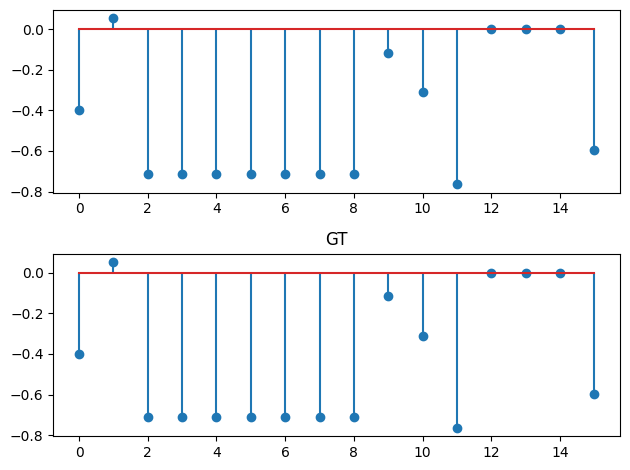

In [77]:
plt.subplot(2,1,1), plt.stem(tf.squeeze(yhat).numpy())
plt.subplot(2,1,2), plt.stem(tf.squeeze(y1n).numpy()), plt.title('GT')
plt.tight_layout()


In [78]:
tf.reduce_sum(tf.square(yhat)), tf.reduce_sum(tf.square(y1n)), 

(<tf.Tensor: shape=(), dtype=float32, numpy=4.756748199462891>,
 <tf.Tensor: shape=(), dtype=float32, numpy=4.756748199462891>)